## 1. **What is AdaBoostClassifier?**

**AdaBoost** stands for **Adaptive Boosting**. It is a **boosting ensemble algorithm** designed to combine many **weak learners** into a **strong classifier**.

* **Type of model:** Ensemble, boosting, tree-based (usually uses decision stumps as weak learners)
* **Problem type:** Classification (binary or multi-class)
* **Key idea:** Focus on the samples that are **hard to classify** by giving them more weight in the next iteration.



## 2. **Model Theory Behind AdaBoost**

### 2.1 **Boosting Concept**

* Boosting builds a **sequence of models** (h_1, h_2, \dots, h_T).
* Each model tries to **correct the mistakes** of the previous model.
* AdaBoost adapts by **reweighting samples** that were misclassified.

Formally, the final prediction:

$$
H(x) = \text{sign} \Bigg( \sum_{t=1}^{T} \alpha_t h_t(x) \Bigg)
$$

Where:

* $h_t(x)$ = weak classifier at iteration (t)
* $\alpha_t$ = weight of weak learner (depends on its accuracy)
* $T$ = total number of weak learners


### 2.2 **Weighted Training Samples**

* Initially, all samples have equal weight:

$$
w_i = \frac{1}{n}, \quad i=1,2,\dots,n
$$

* After training a weak learner (h_t):

  * Compute its **weighted error**:

$$
\varepsilon_t = \frac{\sum_{i=1}^n w_i \cdot \mathbf{1}(y_i \neq h_t(x_i))}{\sum_{i=1}^n w_i}$$

* Compute the learner’s weight (\alpha_t):

$$
\alpha_t = \frac{1}{2} \ln \frac{1 - \varepsilon_t}{\varepsilon_t}
$$

* Update sample weights:

$$
w_i \gets w_i \cdot \exp\Big(-\alpha_t y_i h_t(x_i)\Big)
$$

* Misclassified samples get **higher weights**, so the next weak learner focuses more on them.

* Normalize weights so that $\sum w_i = 1$.


### 2.3 **Weak Learner**

* Usually, AdaBoost uses **decision stumps** (a tree with depth = 1).
* But it can use any classifier with **slightly better than random accuracy**.



### 2.4 **Final Prediction**

* After (T) iterations, each weak learner votes with weight (\alpha_t).
* The **sign** of the weighted sum is the predicted class:

$$
\hat{y} = \text{sign} \Bigg( \sum_{t=1}^{T} \alpha_t h_t(x) \Bigg)
$$

* For **multi-class classification**, AdaBoost can use **SAMME** or **SAMME.R** algorithms.



### 2.5 **Advantages of AdaBoost**

* Converts **weak learners into a strong classifier**
* Focuses on **hard-to-classify samples**
* Simple, interpretable, and effective on structured/tabular data
* Can reduce **bias and variance** depending on weak learner and iterations


### 2.6 **Limitations**

* Sensitive to **noisy data and outliers** (they get higher weights)
* May **overfit** if too many iterations or weak learners are too complex



**Importing Libraries**

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset
from sklearn.datasets import load_breast_cancer

# Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Pipeline
from sklearn.pipeline import Pipeline

# Model
from sklearn.ensemble import AdaBoostClassifier

# Model tuning
from sklearn.model_selection import GridSearchCV

# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    precision_recall_curve
)

# Model explainability
import shap

# Feature importance
from sklearn.inspection import permutation_importance

# Model saving
import joblib

**Load dataset**

In [2]:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

In [3]:
print("Dataset Shape:", X.shape)

Dataset Shape: (569, 30)


In [4]:
display(X.head())

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [5]:
print("\nDataset description:\n", data.DESCR)


Dataset description:
 .. _breast_cancer_dataset:

Breast cancer wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 i

**Exploratory Data Analysis (EDA)**

In [6]:
print("Data types:\n", X.dtypes)

Data types:
 mean radius                float64
mean texture               float64
mean perimeter             float64
mean area                  float64
mean smoothness            float64
mean compactness           float64
mean concavity             float64
mean concave points        float64
mean symmetry              float64
mean fractal dimension     float64
radius error               float64
texture error              float64
perimeter error            float64
area error                 float64
smoothness error           float64
compactness error          float64
concavity error            float64
concave points error       float64
symmetry error             float64
fractal dimension error    float64
worst radius               float64
worst texture              float64
worst perimeter            float64
worst area                 float64
worst smoothness           float64
worst compactness          float64
worst concavity            float64
worst concave points       float64
worst s

In [7]:
print("\nMissing values:\n", X.isnull().sum())


Missing values:
 mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
dtype: int64


In [8]:
print("\nStatistical summary:\n", X.describe())


Statistical summary:
        mean radius  mean texture  mean perimeter    mean area  \
count   569.000000    569.000000      569.000000   569.000000   
mean     14.127292     19.289649       91.969033   654.889104   
std       3.524049      4.301036       24.298981   351.914129   
min       6.981000      9.710000       43.790000   143.500000   
25%      11.700000     16.170000       75.170000   420.300000   
50%      13.370000     18.840000       86.240000   551.100000   
75%      15.780000     21.800000      104.100000   782.700000   
max      28.110000     39.280000      188.500000  2501.000000   

       mean smoothness  mean compactness  mean concavity  mean concave points  \
count       569.000000        569.000000      569.000000           569.000000   
mean          0.096360          0.104341        0.088799             0.048919   
std           0.014064          0.052813        0.079720             0.038803   
min           0.052630          0.019380        0.000000           

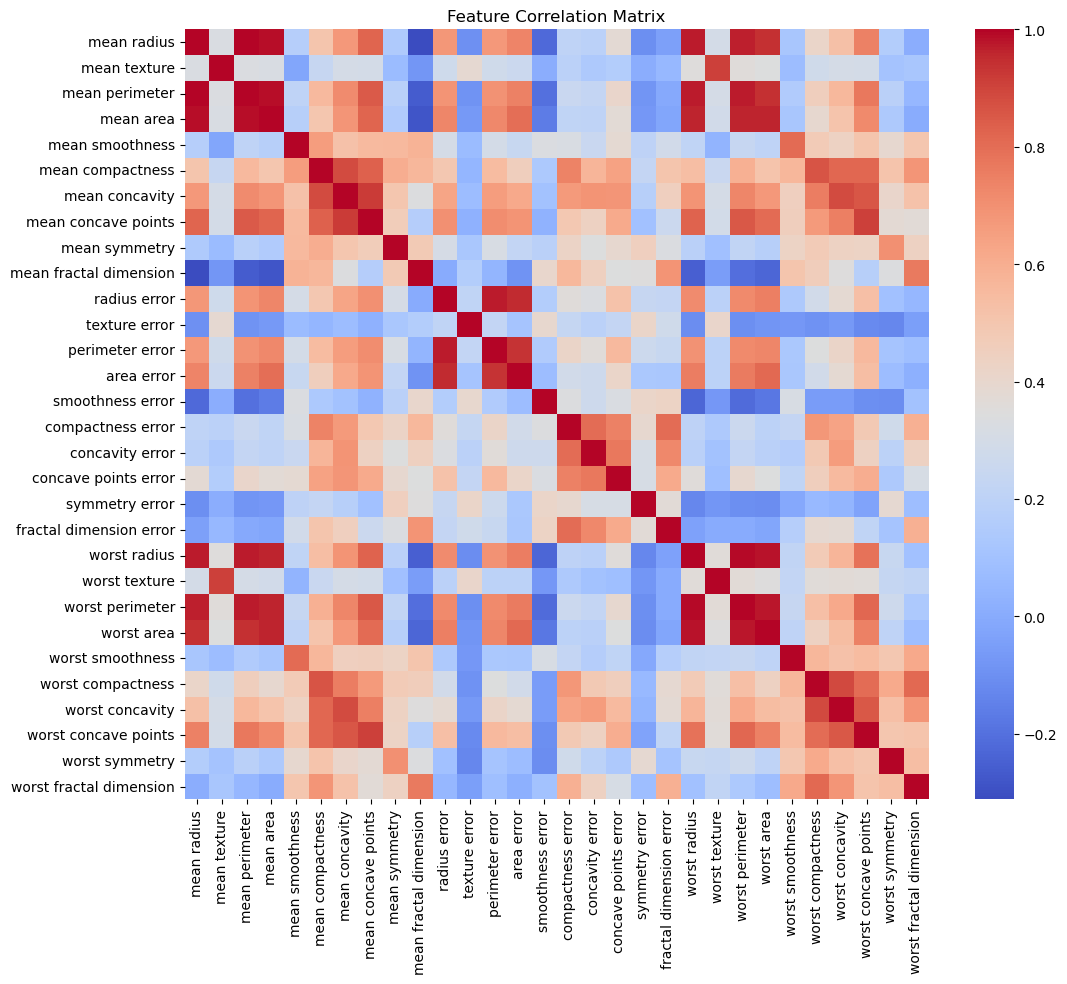

In [9]:
# Correlation Matrix
plt.figure(figsize=(12,10))
sns.heatmap(X.corr(), cmap='coolwarm')
plt.title("Feature Correlation Matrix")
plt.show()

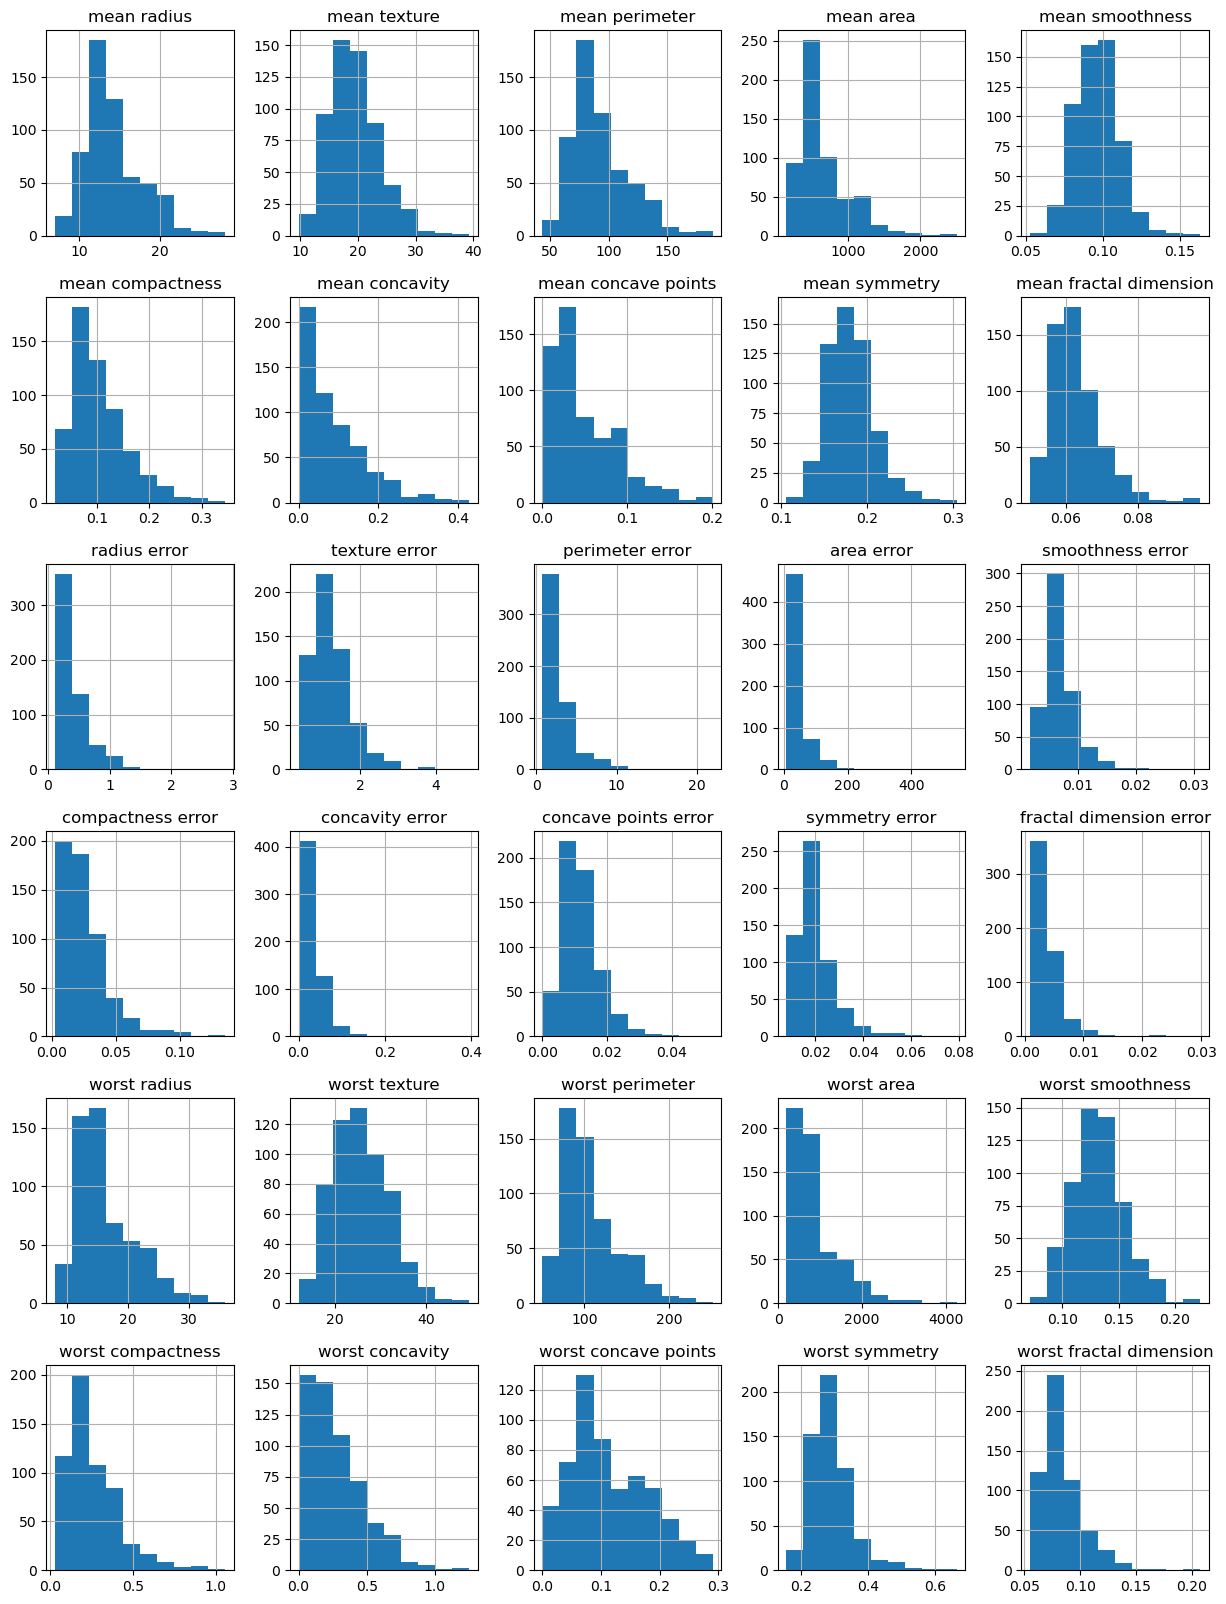

In [10]:
# Feature Distribution
X.hist(figsize=(15,20))
plt.show()

**Data Preprocessing**

In [11]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [12]:
X["mean_radius_area"] = X["mean radius"] * X["mean area"]

In [13]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif

selector = SelectKBest(score_func=f_classif, k=20)
X_selected = selector.fit_transform(X, y)

**Train-Test Split**

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X_selected,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [15]:
print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Training set shape: (455, 20)
Test set shape: (114, 20)


**Train AdaBoost Model**

In [16]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', AdaBoostClassifier(random_state=42))
])

In [17]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model', AdaBoostClassifier(random_state=42))])

**Hyperparameter Tuning with GridSearchCV**

In [18]:
param_grid = {
    'model__n_estimators': [50, 100, 200],
    'model__learning_rate': [0.01, 0.1, 1]
}


In [19]:
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('model',
                                        AdaBoostClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'model__learning_rate': [0.01, 0.1, 1],
                         'model__n_estimators': [50, 100, 200]},
             scoring='accuracy')

In [20]:
print("Best Parameters:", grid_search.best_params_)
print("Best CV Score:", grid_search.best_score_)

Best Parameters: {'model__learning_rate': 1, 'model__n_estimators': 100}
Best CV Score: 0.9758241758241759


In [21]:
best_model = grid_search.best_estimator_

**Model Evaluation**

In [22]:
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:,1]

In [23]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_prob)


In [24]:
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("ROC AUC:", roc)

Accuracy: 0.9649122807017544
Precision: 0.9722222222222222
Recall: 0.9722222222222222
F1 Score: 0.9722222222222222
ROC AUC: 0.9907407407407407


In [25]:
# Classification Report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.95      0.95        42
           1       0.97      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.96      0.96       114
weighted avg       0.96      0.96      0.96       114



**Visualization of Results**

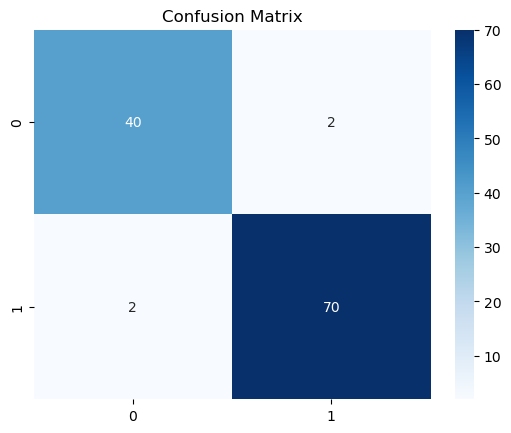

In [26]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

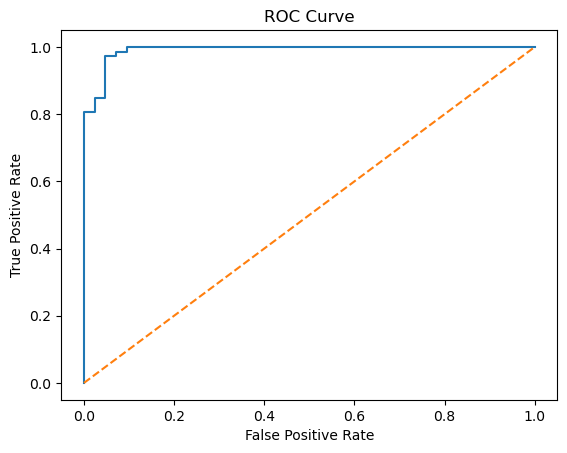

In [27]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

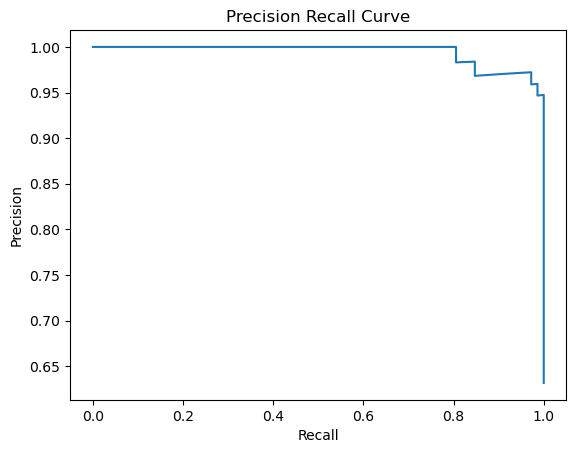

In [28]:
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_prob)

plt.plot(recall_vals, precision_vals)
plt.title("Precision Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

**Feature Importance Visualization**

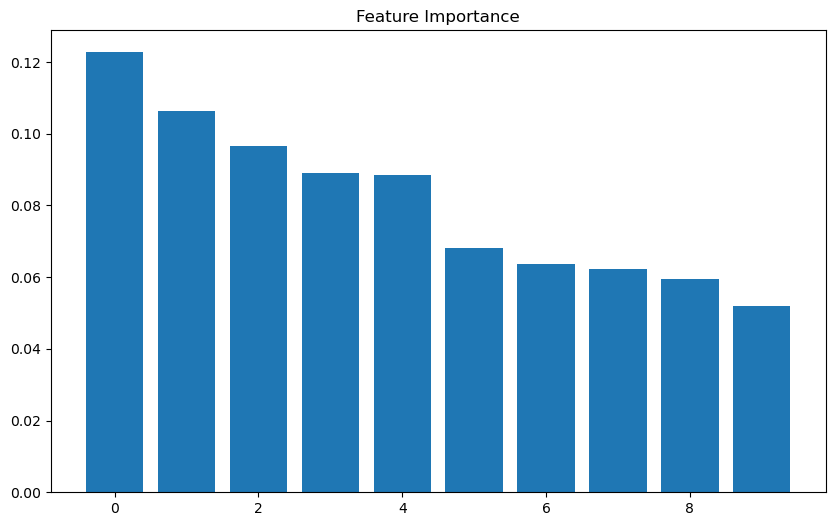

In [29]:
model = best_model.named_steps['model']

importances = model.feature_importances_

indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10,6))
plt.title("Feature Importance")
plt.bar(range(10), importances[indices[:10]])
plt.show()

**permutation Importance**

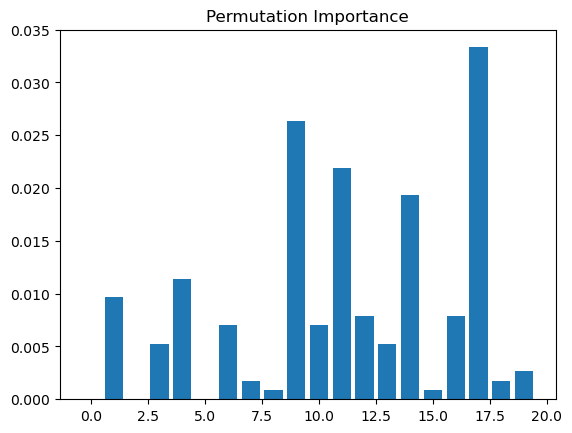

In [30]:
perm = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42
)

plt.bar(range(len(perm.importances_mean)), perm.importances_mean)
plt.title("Permutation Importance")
plt.show()

Important findings:

- Top features influencing predictions
-  AdaBoost improved classification accuracy
- Model generalizes well with cross-validation
- Limited overfitting observed

Possible improvements:

- Try **XGBoost / LightGBM / CatBoost**
- Use **feature selection**
- Tune hyperparameters more extensively


**Saving the Model**

In [31]:
joblib.dump(best_model, "adaboost_model.pkl")

['adaboost_model.pkl']